In this notebook, we will compute the local antibody brightness for each relevant immunofluorescence rounds.

Relevant figures can be found in Figure 2, Extended Data Figure 3

In [1]:
import os
import numpy as np
import pandas as pd
import sys

In [2]:
sys.path.append('../scripts/')
from ioMicroS6A import *
from ecDNATracer_antibody import *
from plot import *

# compute local antibody brightness

In [7]:
dic_iA_flds = {1: 'A1_H3K9me3_Pol2S2_set1', 2:'A1_H3K9me3_Pol2S2_set1',
              4: 'A2_SC35_H3K27Ac_set1', 5: 'A2_SC35_H3K27Ac_set1',
              7: 'A3_Lam_Nup98-high_set1',8:'A3_Lam_Nup98-high_set1'}
dic_iA_Around = {1:'A1_R1_2_3',2:'A1_R1_2_3',
                4: 'A2_R4_5_6', 5: 'A2_R4_5_6',
                7: 'A3_Lam_Nup98-high', 8: 'A3_Lam_Nup98-high'}
dic_iA_antibody = {1: 'H3K9me3', 2: 'Pol2S2',
                   4: 'SC35', 5: 'H3K27Ac',
                  7: 'LAMA1', 8: 'NUP98'}

dic_iA_antibody_fullname = {1: 'H3K9me3', 2: 'p-RNA polymerase II', 4: 'Spliceosome', 5: 'H3K27Ac', 7: 'Lamina A/C', 8: 'NUP98'}

pix_size = [0.4, 0.108333, 0.108333]

## compute local antibody brightness

In [34]:
df_summary_full = pd.read_csv('C:/GBM39/invirto_030125/121225__df-global_transcription-rgs-antibody_H__invitro_030125.csv',
                index_col = 0)

In [35]:
df_summary_full['ifov'] = df_summary_full['cell_id'].astype(int) // 10**5
uifovs_full = np.unique(np.array(df_summary_full['cell_id']) // 10**5)
len(uifovs_full)

31

In [21]:
import pickle
with open(r'D:\GBM39\ecDNATracer\gridSearch_traces_chromabb___invitro_03012025\BT__preEM_strict_redooffby1_31FOVs__dic_linear_circ_by_type-Rmax1.5.pkl', 'rb') as file:
    dic_linear_circ_by_type = pickle.load(file)
tr_type = 'Xtraces_chrom_inter_73_253_254'
linear_traces, circ_traces = dic_linear_circ_by_type[tr_type]
linear_traces.shape, circ_traces.shape

((849, 252, 6), (35969, 252, 6))

In [22]:
pool_to_traces = {"linear": linear_traces, "circular": circ_traces}

def drift_globber_cellculture(iA):
    if iA in [1, 2, 4, 5]:
        return glob.glob(os.path.join(
            r"Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__polII_analysis", "drift*"
        ))
    else:
        return glob.glob(os.path.join(
            r"Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__lamina_analysis", "*drift*"
        ))

def fld_from_iA_cellculture(iA):
    return rf"\\132.239.200.19\banana1\dragonfruit1\CellCulture_EGFR_03_01_2025\{dic_iA_flds[iA]}"


In [45]:
## run it for all fovs
df_ab_full = df_summary_full.copy()
df_ab_full = df_ab_full.drop(columns = ['iA2_ab_norm_robust_H','iA4_ab_norm_robust_H','iA5_ab_norm_robust_H'])
for iA in [2,5,7]:
# for iA in [2]:
    df_plot_full = get_antibody_norm_brightness_zscore_streaming(
        iA=iA,
        df_meta=df_ab_full,
        ufovs=uifovs_full,
        use_robust_std=True,
        batch_size_fovs=1,
        fov_from_ifov=lambda ifov: f"Conv_zscan1__{str(int(ifov)).zfill(3)}",
        drift_globber=drift_globber_cellculture,
        fld_from_iA=fld_from_iA_cellculture,
        flat_field_tag=r"\\132.239.200.19\banana1\RenImaging2\Brett\CellCulture_EGFR_03_01_2025\flat_field",
        pool_to_traces=pool_to_traces,
        pix_size=pix_size,
    )

 10%|████████                                                                           | 3/31 [00:24<03:52,  8.29s/it]C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_5512\3056736661.py:77: RuntimeWarning: Mean of empty slice
  mean_brightness = np.nanmean(intensities, axis=1).astype(np.float32)
 16%|█████████████▍                                                                     | 5/31 [00:41<03:44,  8.62s/it]C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_5512\3056736661.py:77: RuntimeWarning: Mean of empty slice
  mean_brightness = np.nanmean(intensities, axis=1).astype(np.float32)
 71%|██████████████████████████████████████████████████████████▏                       | 22/31 [03:16<01:21,  9.06s/it]C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_5512\3056736661.py:77: RuntimeWarning: Mean of empty slice
  mean_brightness = np.nanmean(intensities, axis=1).astype(np.float32)
 10%|████████                                                                           | 3/31 [00:27<04:1

In [46]:
df_plot_full[(df_plot_full['cell_id'] == 2000004) & (df_plot_full['global_row'] == 12)]

,cell_id,pool,trace_id,global_row,EGFR,EGFR-AS1,LANCL2,FKBP9P1,SEPTIN14,ZNF713,...,matrix_name,centroid,dist_to_com,dist_to_lamina,inside_nucleus,rgs,ifov,iA2_ab_norm_robust_H,iA5_ab_norm_robust_H,iA7_ab_norm_robust_H
14,2000004,circular,12,12,0,1,1,0,0,0,...,circular,"(4.333360772974353, 194.72745666357434, 44.500...",9.221877,0.676643,True,0.340262,20,0.723715,-2.030993,2.903324


## plot 3 way correlation

In [48]:
## split to ecDNA only
df_summary_circ = df_plot_full[df_plot_full['pool'] == 'circular']
df_summary_circ.shape

(34349, 28)

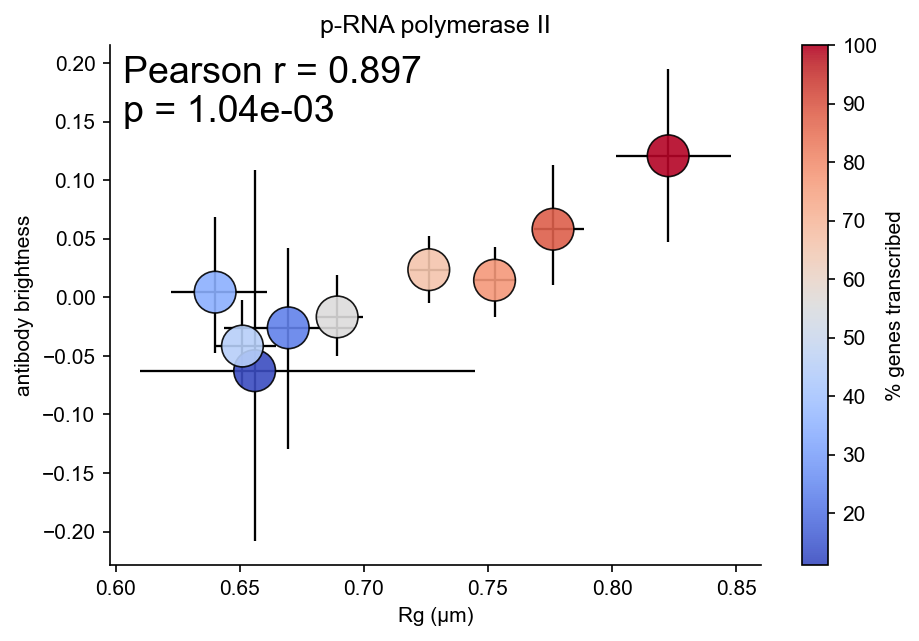

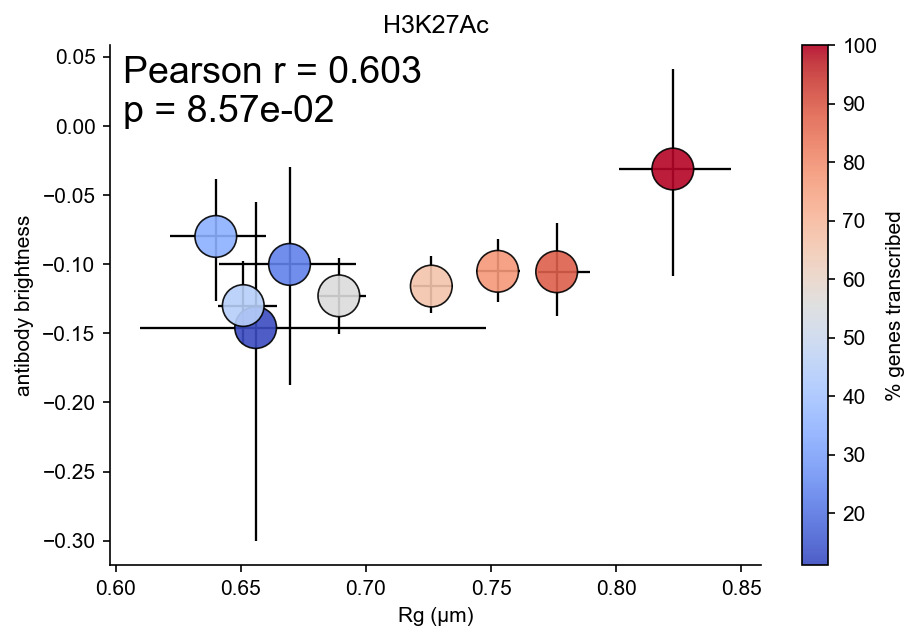

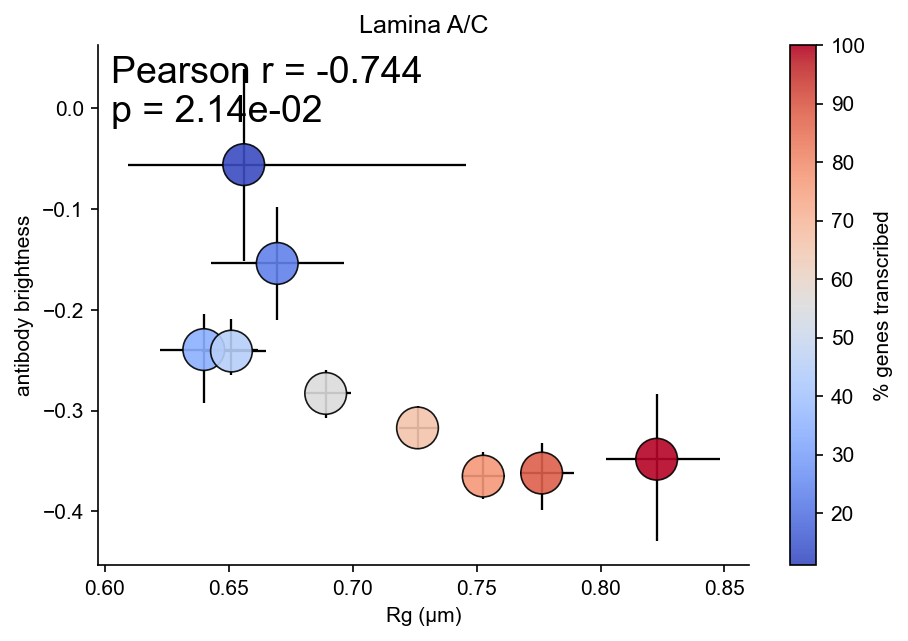

In [49]:
## plot each one of them and save
for iA in [2,5,7]:
    dotplot_bootstrap_median_with_pearson(
            df_summary_circ,
            cmap="coolwarm",  # blue->red
            figsize=(7,4.5),
            s=400,
            x_col = 'rgs',
            y_col =  f"iA{iA}_ab_norm_robust_H",
            z_col = 'total_genes_transcribed',
            x_label="Rg (µm)",
            y_label= 'antibody brightness',
            z_label = '% genes transcribed',
            title = dic_iA_antibody_fullname[iA],
            # save_svg = None,
            group_col = 'total_genes_transcribed',
            n_groups = None,
            ax = None,
            z_to_percent=True,
            # save_svg= f"C:/GBM39/manuscript_figures/invitro_fig2/plots/antibody_brightness_updated/ecDNA_antibody_iA{iA}_{dic_iA_antibody[iA]}__rgs_H_dotplot_nonumber_withPearson.svg"
        )


# global antibody

This computes the average brightness across an entire cell to see if a cell has a globally higher transcriptional state

## compute global brightness

In [54]:
df_ecDNA_mean = df_summary_circ.groupby('cell_id').mean().reset_index()

C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_5512\2430250278.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_ecDNA_mean = df_summary_circ.groupby('cell_id').mean().reset_index()


In [57]:
df_ecDNA_mean['ifov'] = df_ecDNA_mean['cell_id'] // 10**5
df_ecDNA_mean['icell'] = df_ecDNA_mean['cell_id'] % 10**5

In [58]:
import os, glob
import numpy as np
import pandas as pd

dfs_long = []

for iA in [2, 5]:

    # choose drift directory once per iA
    if iA in [1, 2, 4, 5]:
        drift_fls = glob.glob(os.path.join(
            r'Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__polII_analysis', 'drift*'
        ))
    else:
        drift_fls = glob.glob(os.path.join(
            r'Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__lamina_analysis', '*drift*'
        ))

    for ifov in tqdm(uifovs_full):
        fov = f'Conv_zscan1__{int(ifov):03d}'

        ## load dapi segm
        dapi_segm_ifov = np.load(
            rf'Y:\dragonfruit1\CellCulture_EGFR_03_01_2025__merged_Segmentation\{fov}--Q11_MER_set1--dapi-cyto_segm.npz'
        )['dapi_segm']

        dic_drifts = get_dic_drifts(fov, drift_fls=drift_fls)

        cell_ids = df_ecDNA_mean.loc[
            df_ecDNA_mean['ifov'] == ifov, 'icell'
        ].to_numpy()

        df_tmp = compute_global_cell_mean_from_dapi_segm_with_drift(
            fov=fov,
            iA=iA,
            cell_ids=cell_ids,
            dapi_segm_zxy_ds=dapi_segm_ifov,
            drft_zxy=dic_drifts[dic_iA_Around[iA]],
            return_pixel_counts= True
        )

        # rename mean column → generic name
        mean_col = f"iA{iA}_global_cell_mean"
        df_tmp = df_tmp.rename(columns={mean_col: "mean_val"})

        df_tmp["iA"] = iA
        df_tmp["ifov"] = ifov

        dfs_long.append(df_tmp)

df_long = pd.concat(dfs_long, ignore_index=True)


100%|██████████████████████████████████████████████████████████████████████████████████| 31/31 [05:12<00:00, 10.07s/it]


In [59]:
## convert to wide style
df_plot = (
    df_long
    .pivot_table(
        index=["ifov", "cell_id"],
        columns="iA",
        values="mean_val"
    )
    .rename(columns=lambda x: f"iA{x}_global_cell_mean")
    .reset_index()
)
df_plot

iA,ifov,cell_id,iA2_global_cell_mean,iA5_global_cell_mean
0,20,2000004,4.417857,3.903055
1,20,2000005,2.900356,2.503513
2,20,2000007,2.656438,2.347482
3,20,2000009,4.418358,4.213637
4,20,2000011,4.113666,3.709762
...,...,...,...,...
488,50,5000027,3.666308,3.557278
489,50,5000028,3.782498,3.754555
490,50,5000029,2.794453,3.150123
491,50,5000032,3.034606,2.577406


In [63]:
df_ecDNA_mean = pd.merge(df_plot, df_ecDNA_mean, on = 'cell_id')

In [65]:
df_ecDNA_mean.columns

Index(['ifov_x', 'cell_id', 'iA2_global_cell_mean', 'iA5_global_cell_mean',
       'trace_id', 'global_row', 'EGFR', 'EGFR-AS1', 'LANCL2', 'FKBP9P1',
       'SEPTIN14', 'ZNF713', 'MRPS17', 'NIPSNAP2', 'PSPH',
       'total_genes_transcribed', 'avg_NN_dist', 'has_anchor', 'anchor_index',
       'anchor_brightness', 'dist_to_com', 'dist_to_lamina', 'inside_nucleus',
       'rgs', 'ifov_y', 'iA2_ab_norm_robust_H', 'iA5_ab_norm_robust_H',
       'iA7_ab_norm_robust_H', 'icell'],
      dtype='object')

In [66]:
df_ecDNA_mean['pct_genes_transcribed'] = df_ecDNA_mean['total_genes_transcribed'] / 9

## plot

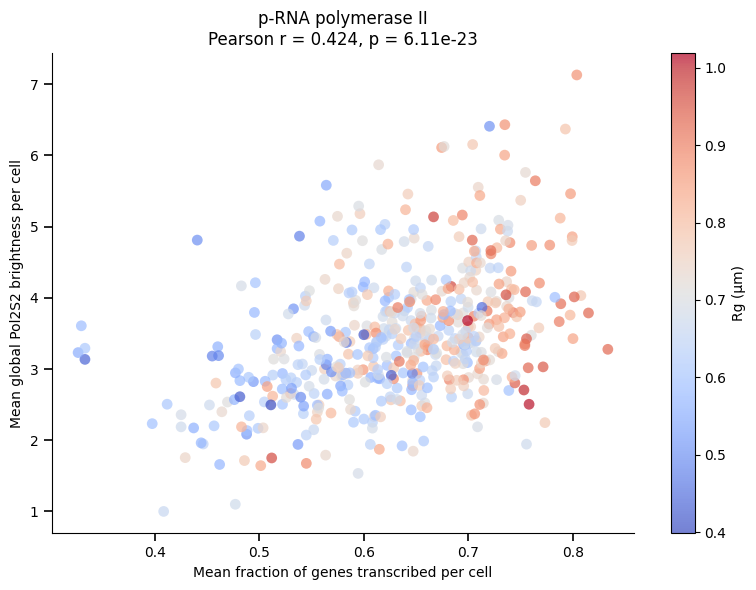

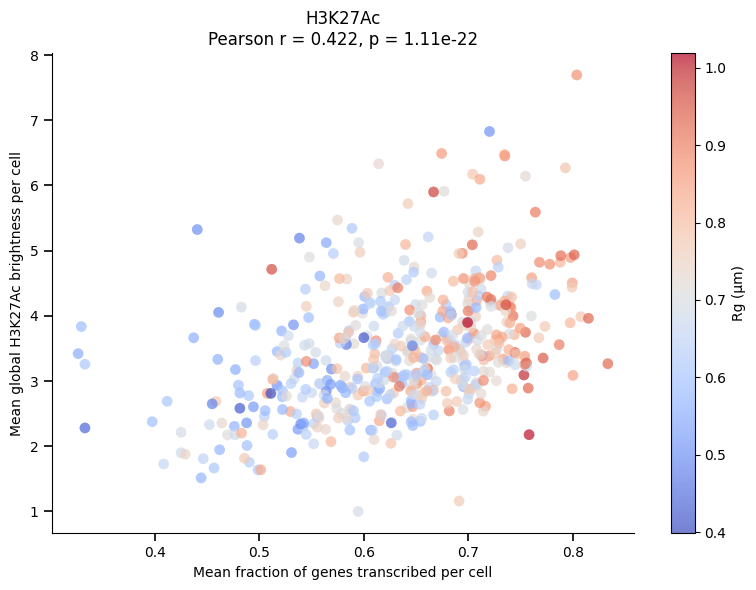

In [67]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# --- keep text as editable text in SVG ---
mpl.rcParams["svg.fonttype"] = "none"


for iA in [2,5]:

    # --- keep text as editable text in SVG ---
    mpl.rcParams["svg.fonttype"] = "none"

    x = df_ecDNA_mean['pct_genes_transcribed']
    y = df_ecDNA_mean[f'iA{iA}_global_cell_mean']
    z = df_ecDNA_mean['rgs']

    mask = x.notna() & y.notna() & z.notna()
    x = x[mask]
    y = y[mask]
    z = z[mask]

    if len(x) > 1:
        r, p = pearsonr(x, y)
    else:
        r, p = np.nan, np.nan

    fig, ax = plt.subplots(figsize=(8, 6))

    sc = ax.scatter(
        x,
        y,
        c=z,
        cmap='coolwarm',
        s=60,
        alpha=0.7,
        edgecolors='none',
        rasterized=True,  
    )

    ax.set_xlabel('Mean fraction of genes transcribed per cell')
    ax.set_ylabel(f'Mean global {dic_iA_antibody[iA]} brightness per cell')
    ax.set_title(f'{dic_iA_antibody_fullname[iA]}\nPearson r = {r:.3f}, p = {p:.2e}')

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",     # outward ticks (journal style)
        bottom=True,
        top=False,
        left=True,
        right=False,
        length=6,            # tick length
        width=1.2,           # tick thickness
    )

    cb = plt.colorbar(sc, ax=ax)
    cb.set_label('Rg (µm)')

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    # --- save SVG ---
    # fig.savefig(
    #     f"C:/GBM39/manuscript_figures/invitro_fig2/plots/cell_level_antibody/scatter_entirecell__{dic_iA_antibody[iA]}_meanH_brightness.svg",
    #     format="svg",
    #     bbox_inches="tight",
    #     dpi=600,   # only affects rasterized elements
    # )

    plt.show()

